# Time Series as a Regression Problem — Solution Notebook

**Assignment:** `regression_homework.md`
**Dataset:** AirPassengers — monthly international airline passengers, Jan 1949 – Dec 1960 (144 observations)

Instead of a specialised sequential model (ARIMA, exponential smoothing, state-space),
this notebook reframes forecasting as **supervised regression** using a
**sliding-window / lag-feature** transformation, and fits a
[**TabPFN**](https://github.com/PriorLabs/TabPFN) regressor to it.

## Contents

| Section | Content |
|---|---|
| 1 | Data loading, sliding-window feature engineering, chronological split |
| 2 | Exploratory data analysis (summary, distributions, correlations, pairplot, seasonal decomposition, autocorrelation) |
| 3 | Model training with `TabPFNRegressor` + baselines, metrics, residual analysis |
| 4 | Model interpretation, feature importance, recursive multi-step forecast, limitations |
| 5 | Flask REST API (`timeseries_regression_api.py`) generated and smoke-tested in-notebook |

**Artifacts written by this notebook** (all names prefixed `timeseries_regression_*` so
nothing from the earlier `air_passengers_analysis.ipynb` run is overwritten):

- `timeseries_regression_supervised.csv` — the transformed supervised dataset
- `tabpfn_timeseries_regression_model.pkl` — the trained model
- `timeseries_regression_scaler.pkl` — the fitted `StandardScaler`
- `timeseries_regression_metadata.json` — window size, feature order, metrics
- `timeseries_regression_api.py` — the Flask service

## 0. Setup

In [1]:
import json
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

# ---- configuration -------------------------------------------------------
DATA_URL = ("https://raw.githubusercontent.com/AileenNielsen/"
            "TimeSeriesAnalysisWithPython/master/data/AirPassengers.csv")
LOCAL_CSV = Path("AirPassengers.csv")      # offline fallback / cache
WINDOW_SIZE = 6                            # months of history used as features
TEST_FRACTION = 0.2                        # chronological hold-out
SEASONAL_PERIOD = 12                       # months per year
RANDOM_STATE = 42

SUPERVISED_CSV = Path("timeseries_regression_supervised.csv")
MODEL_PATH = Path("tabpfn_timeseries_regression_model.pkl")
SCALER_PATH = Path("timeseries_regression_scaler.pkl")
META_PATH = Path("timeseries_regression_metadata.json")
API_PATH = Path("timeseries_regression_api.py")

np.random.seed(RANDOM_STATE)
print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 2.2.3 | numpy 1.26.4


## 1. Data Preparation and Feature Engineering

### 1.1 Load the raw time series

The dataset is pulled from the URL given in the assignment. A local copy is kept as
`AirPassengers.csv` so the notebook still runs without a network connection.

In [2]:
try:
    df = pd.read_csv(DATA_URL)
    df.to_csv(LOCAL_CSV, index=False)          # refresh the offline cache
    source = "remote URL"
except Exception as exc:                        # offline -> fall back to cache
    if not LOCAL_CSV.exists():
        raise RuntimeError(f"download failed ({exc}) and no local {LOCAL_CSV}") from exc
    df = pd.read_csv(LOCAL_CSV)
    source = f"local cache ({LOCAL_CSV})"

# 'Month' -> DatetimeIndex, monthly-start frequency
df["Month"] = pd.to_datetime(df["Month"])
df.set_index("Month", inplace=True)
df = df.asfreq("MS")

series = df["#Passengers"]

print(f"Loaded from {source}")
print(f"Shape           : {df.shape}")
print(f"Date range      : {series.index.min():%Y-%m} -> {series.index.max():%Y-%m}")
print(f"Frequency       : {df.index.freqstr}")
print(f"Missing values  : {series.isna().sum()}")
print(f"Duplicated dates: {df.index.duplicated().sum()}")
df.head()

Loaded from remote URL
Shape           : (144, 1)
Date range      : 1949-01 -> 1960-12
Frequency       : MS
Missing values  : 0
Duplicated dates: 0


,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


### 1.2 Sliding-window transformation (time series → supervised learning)

For every month *t* the previous `WINDOW_SIZE = 6` observations become the feature
vector `[lag_6, lag_5, lag_4, lag_3, lag_2, lag_1]` (oldest → newest) and the value at
month *t* is the target. The first 6 rows produce `NaN` lags and are dropped.

In [3]:
def create_features(data, window_size=WINDOW_SIZE):
    """
    Transform time series to supervised learning with a sliding window.

    Parameters
    ----------
    data : pandas Series
        The time series data (DatetimeIndex).
    window_size : int
        Number of previous time steps to use as features.

    Returns
    -------
    X : pandas DataFrame
        Feature matrix with `window_size` columns, ordered oldest -> newest
        (lag_{window_size} ... lag_1).
    y : pandas Series
        Target variable (the value at the current time step).
    """
    X = pd.DataFrame(index=data.index)

    # lag_window_size ... lag_1  => oldest month first, most recent month last
    for i in range(window_size, 0, -1):
        X[f"lag_{i}"] = data.shift(i)

    y = data.copy()

    # rows whose window is incomplete carry NaNs -> drop them, realign y
    X = X.dropna()
    y = y.loc[X.index]

    return X, y


X, y = create_features(series, WINDOW_SIZE)
FEATURE_NAMES = list(X.columns)

# features + target in one frame, saved for downstream use
result_df = X.copy()
result_df["target"] = y
result_df.to_csv(SUPERVISED_CSV)

print(f"Original observations : {len(series)}")
print(f"Supervised rows       : {len(X)}  (= {len(series)} - {WINDOW_SIZE})")
print(f"Feature order         : {FEATURE_NAMES}")
print(f"Saved                 : {SUPERVISED_CSV}")
result_df.head()

Original observations : 144
Supervised rows       : 138  (= 144 - 6)
Feature order         : ['lag_6', 'lag_5', 'lag_4', 'lag_3', 'lag_2', 'lag_1']
Saved                 : timeseries_regression_supervised.csv


,lag_6,lag_5,lag_4,lag_3,lag_2,lag_1,target
Month,,,,,,,
1949-07-01,112.000,118.000,132.000,129.000,121.000,135.000,148
1949-08-01,118.000,132.000,129.000,121.000,135.000,148.000,148
1949-09-01,132.000,129.000,121.000,135.000,148.000,148.000,136
1949-10-01,129.000,121.000,135.000,148.000,148.000,136.000,119
1949-11-01,121.000,135.000,148.000,148.000,136.000,119.000,104


In [4]:
# --- sanity check: the engineered window must match the raw series ---------
probe = X.index[0]                                    # first supervised row
expected = series.loc[:probe].iloc[-(WINDOW_SIZE + 1):-1].to_numpy(dtype=float)
assert np.allclose(X.loc[probe].to_numpy(dtype=float), expected)
assert y.loc[probe] == series.loc[probe]
assert not X.isna().any().any()

print(f"Row {probe:%Y-%m}")
print(f"  features (oldest->newest): {X.loc[probe].to_numpy()}")
print(f"  target                   : {y.loc[probe]}")
print("Sliding-window transformation verified.")

Row 1949-07
  features (oldest->newest): [112. 118. 132. 129. 121. 135.]
  target                   : 148
Sliding-window transformation verified.


### 1.3 Chronological train / test split

Time series data **must not be shuffled** — the hold-out set has to lie strictly in the
future of the training set, otherwise the model peeks at information it could not have
had at prediction time.

In [5]:
train_size = int(len(X) * (1 - TEST_FRACTION))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Training set size: {X_train.shape}   {X_train.index.min():%Y-%m} -> {X_train.index.max():%Y-%m}")
print(f"Testing set size : {X_test.shape}   {X_test.index.min():%Y-%m} -> {X_test.index.max():%Y-%m}")
print(f"\nTarget range  train: [{y_train.min():.0f}, {y_train.max():.0f}]")
print(f"Target range  test : [{y_test.min():.0f}, {y_test.max():.0f}]  <- test values exceed the training maximum")

Training set size: (110, 6)   1949-07 -> 1958-08
Testing set size : (28, 6)   1958-09 -> 1960-12

Target range  train: [104, 505]
Target range  test : [310, 622]  <- test values exceed the training maximum


## 2. Exploratory Data Analysis

### 2.1 Statistical summary of the original series

In [6]:
summary = pd.DataFrame({
    "count": [series.count()],
    "mean": [series.mean()],
    "std": [series.std()],
    "min": [series.min()],
    "25%": [series.quantile(.25)],
    "50%": [series.median()],
    "75%": [series.quantile(.75)],
    "max": [series.max()],
    "skew": [series.skew()],
    "kurtosis": [series.kurtosis()],
}, index=["#Passengers"])

print(f"First value ({series.index[0]:%Y-%m}) : {series.iloc[0]:.0f}")
print(f"Last  value ({series.index[-1]:%Y-%m}) : {series.iloc[-1]:.0f}")
print(f"Total growth                : {series.iloc[-1] / series.iloc[0] - 1:.1%}")
print(f"Mean YoY growth             : {series.pct_change(12).mean():.1%}")
summary

First value (1949-01) : 112
Last  value (1960-12) : 432
Total growth                : 285.7%
Mean YoY growth             : 12.9%


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
#Passengers,144,280.299,119.966,104,180.000,265.500,360.500,622,0.583,-0.365


### 2.2 Visualise the original time series

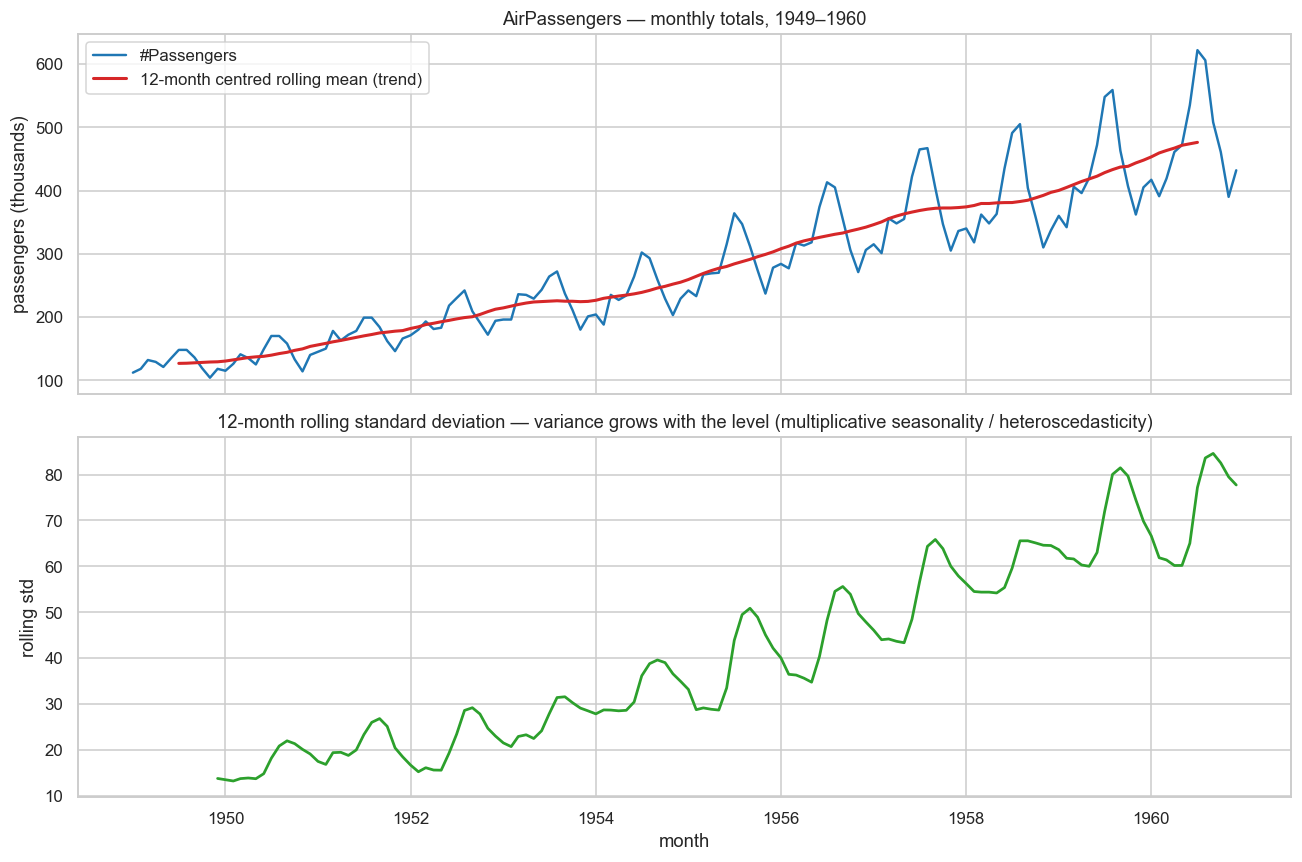

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(series.index, series.values, color="#1f77b4", lw=1.6, label="#Passengers")
axes[0].plot(series.index, series.rolling(12, center=True).mean(),
             color="#d62728", lw=2, label="12-month centred rolling mean (trend)")
axes[0].set_title("AirPassengers — monthly totals, 1949–1960")
axes[0].set_ylabel("passengers (thousands)")
axes[0].legend()

axes[1].plot(series.index, series.rolling(12).std(), color="#2ca02c", lw=1.8)
axes[1].set_title("12-month rolling standard deviation — variance grows with the level "
                  "(multiplicative seasonality / heteroscedasticity)")
axes[1].set_ylabel("rolling std")
axes[1].set_xlabel("month")

plt.tight_layout()
plt.show()

### 2.3 Distribution of the target variable

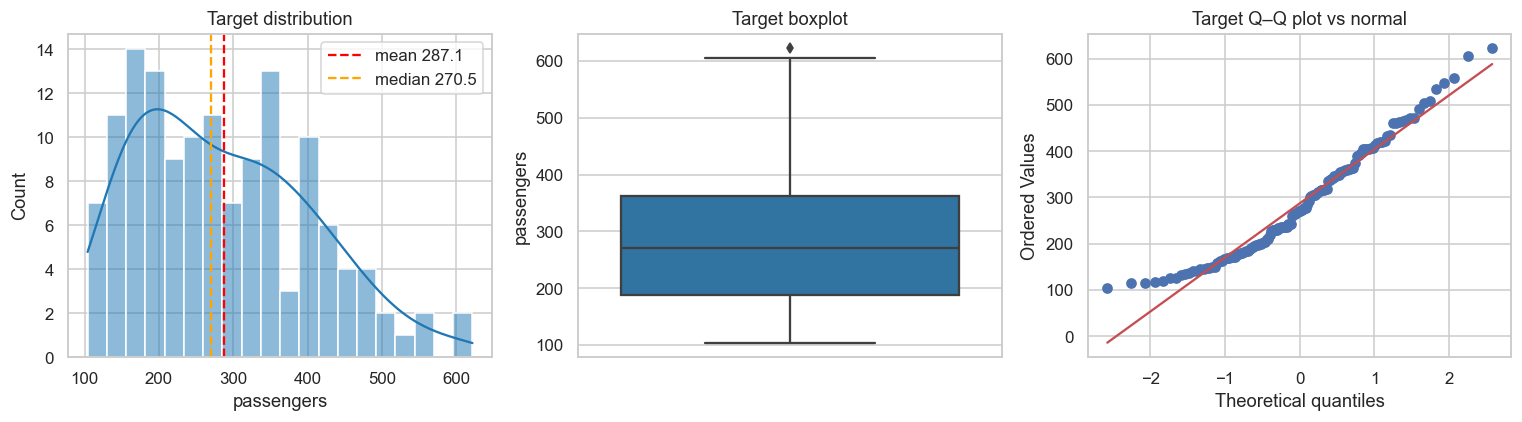

skewness = 0.569  (>0 -> right-tailed)
kurtosis = -0.342
Shapiro–Wilk normality: W=0.9571, p=2.61e-04 -> not normal at alpha=0.05


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.histplot(y, bins=20, kde=True, ax=axes[0], color="#1f77b4")
axes[0].axvline(y.mean(), color="red", ls="--", label=f"mean {y.mean():.1f}")
axes[0].axvline(y.median(), color="orange", ls="--", label=f"median {y.median():.1f}")
axes[0].set_title("Target distribution")
axes[0].set_xlabel("passengers")
axes[0].legend()

sns.boxplot(y=y, ax=axes[1], color="#1f77b4")
axes[1].set_title("Target boxplot")
axes[1].set_ylabel("passengers")

stats.probplot(y, dist="norm", plot=axes[2])
axes[2].set_title("Target Q–Q plot vs normal")

plt.tight_layout()
plt.show()

print(f"skewness = {y.skew():.3f}  (>0 -> right-tailed)")
print(f"kurtosis = {y.kurtosis():.3f}")
sh = stats.shapiro(y)
print(f"Shapiro–Wilk normality: W={sh.statistic:.4f}, p={sh.pvalue:.2e} "
      f"-> {'not normal' if sh.pvalue < 0.05 else 'normal'} at alpha=0.05")

### 2.4 Distributions of the feature variables

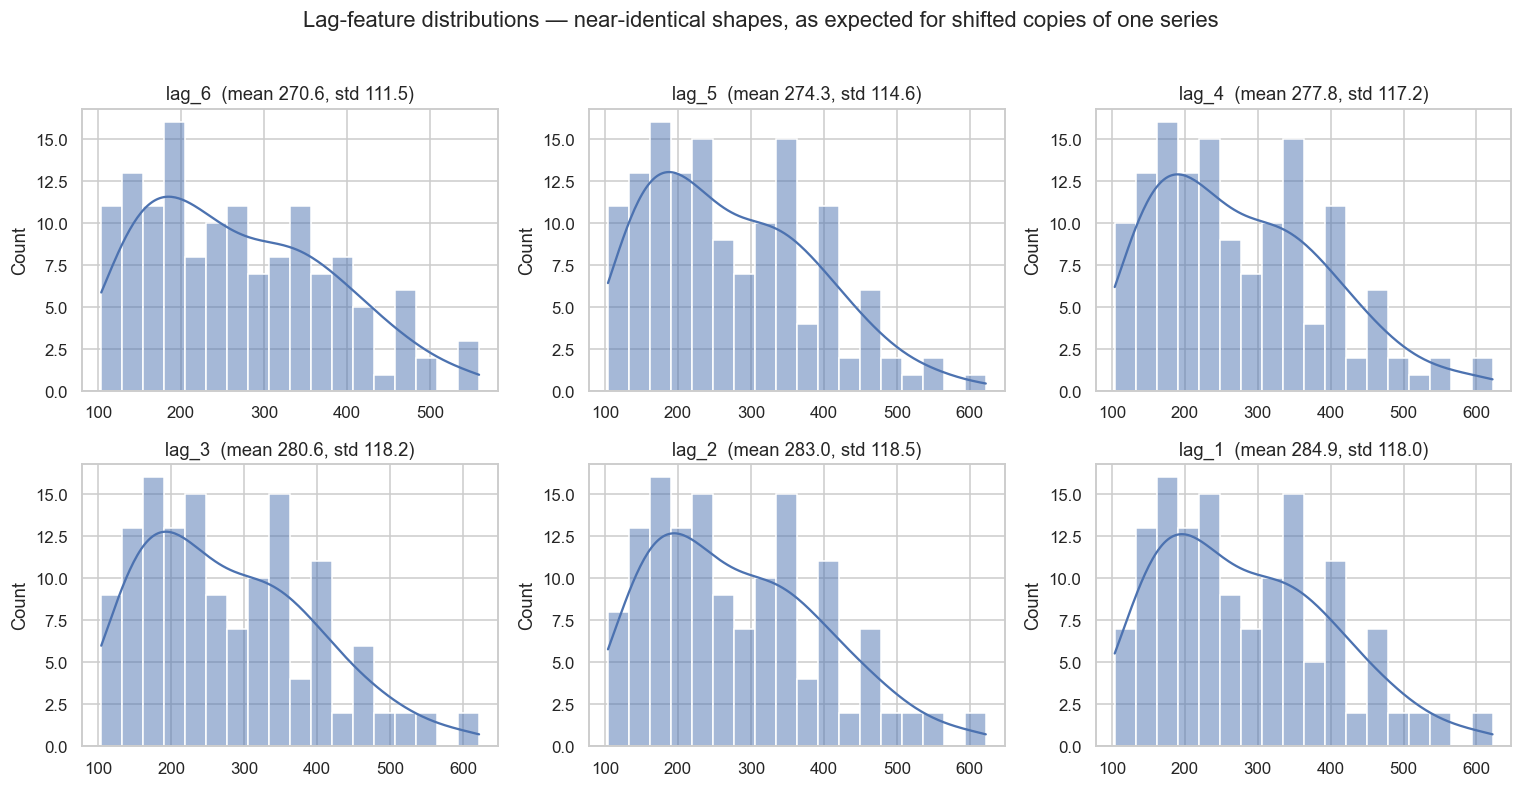

,count,mean,std,min,25%,50%,75%,max
lag_6,138.000,270.609,111.483,104.000,178.500,251.000,353.250,559.000
lag_5,138.000,274.304,114.596,104.000,180.000,261.500,355.000,622.000
lag_4,138.000,277.841,117.237,104.000,180.250,264.000,355.750,622.000
lag_3,138.000,280.565,118.188,104.000,181.500,265.500,358.250,622.000
lag_2,138.000,282.971,118.459,104.000,183.250,268.000,359.750,622.000
lag_1,138.000,284.920,117.987,104.000,185.000,269.500,361.500,622.000


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), FEATURE_NAMES):
    sns.histplot(X[col], bins=18, kde=True, ax=ax, color="#4c72b0")
    ax.set_title(f"{col}  (mean {X[col].mean():.1f}, std {X[col].std():.1f})")
    ax.set_xlabel("")
fig.suptitle("Lag-feature distributions — near-identical shapes, as expected "
             "for shifted copies of one series", y=1.02)
plt.tight_layout()
plt.show()

X.describe().T

### 2.5 Correlations between features and target

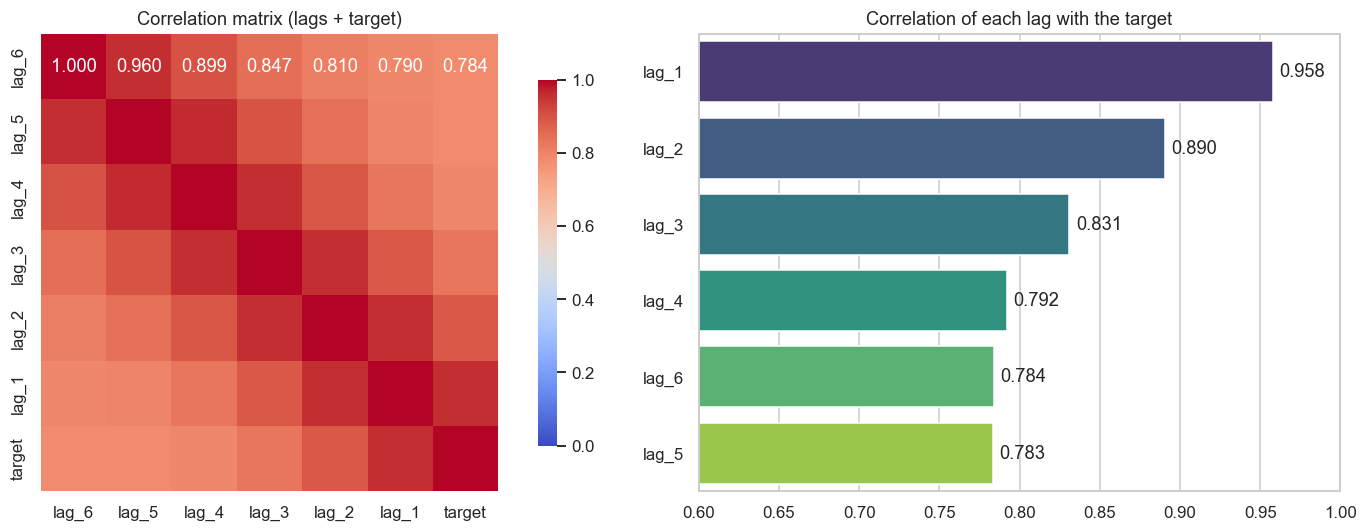

Correlation with target (descending):
lag_1   0.958
lag_2   0.890
lag_3   0.831
lag_4   0.792
lag_6   0.784
lag_5   0.783


In [10]:
corr = result_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                         gridspec_kw={"width_ratios": [1.25, 1]})

sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", vmin=0, vmax=1,
            square=True, cbar_kws={"shrink": .8}, ax=axes[0])
axes[0].set_title("Correlation matrix (lags + target)")

target_corr = corr["target"].drop("target").sort_values(ascending=False)
sns.barplot(x=target_corr.values, y=target_corr.index, ax=axes[1], palette="viridis")
axes[1].set_xlim(0.6, 1.0)
axes[1].set_title("Correlation of each lag with the target")
for i, v in enumerate(target_corr.values):
    axes[1].text(v + 0.004, i, f"{v:.3f}", va="center")

plt.tight_layout()
plt.show()

print("Correlation with target (descending):")
print(target_corr.to_string())

### 2.6 Pairplot — relationships between selected lags and the target

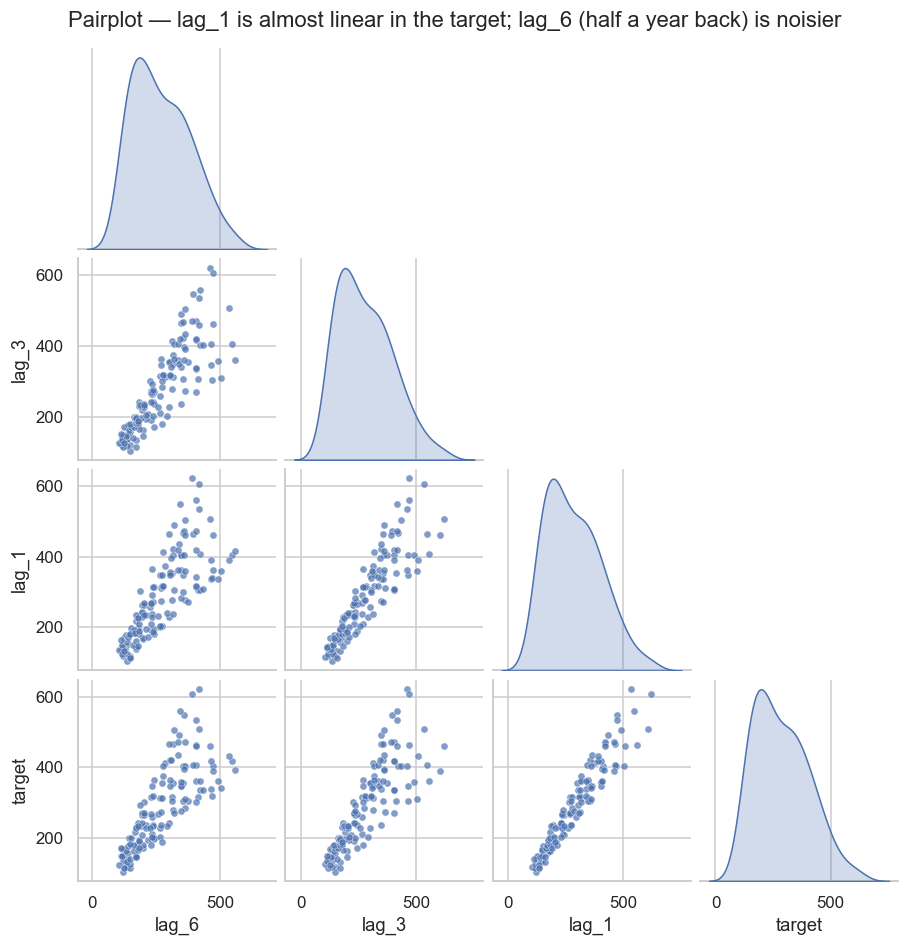

In [11]:
subset = result_df[["lag_6", "lag_3", "lag_1", "target"]]
g = sns.pairplot(subset, diag_kind="kde", plot_kws={"s": 22, "alpha": .7},
                 corner=True, height=2.1)
g.fig.suptitle("Pairplot — lag_1 is almost linear in the target; "
                  "lag_6 (half a year back) is noisier", y=1.02)
plt.show()

### 2.7 Seasonal decomposition

`statsmodels` is not part of this project's environment, so classical decomposition is
implemented directly with a **2×12 centred moving average** — exactly the estimator
`seasonal_decompose` uses for an even period:

- **trend**  = 2×12 centred MA
- **seasonal** = mean of the detrended series per calendar month, normalised
- **residual** = what the trend and seasonal components do not explain

The **multiplicative** model (`y = trend × seasonal × resid`) is the right choice here
because the swing amplitude grows with the level; the additive fit is shown alongside
for comparison.

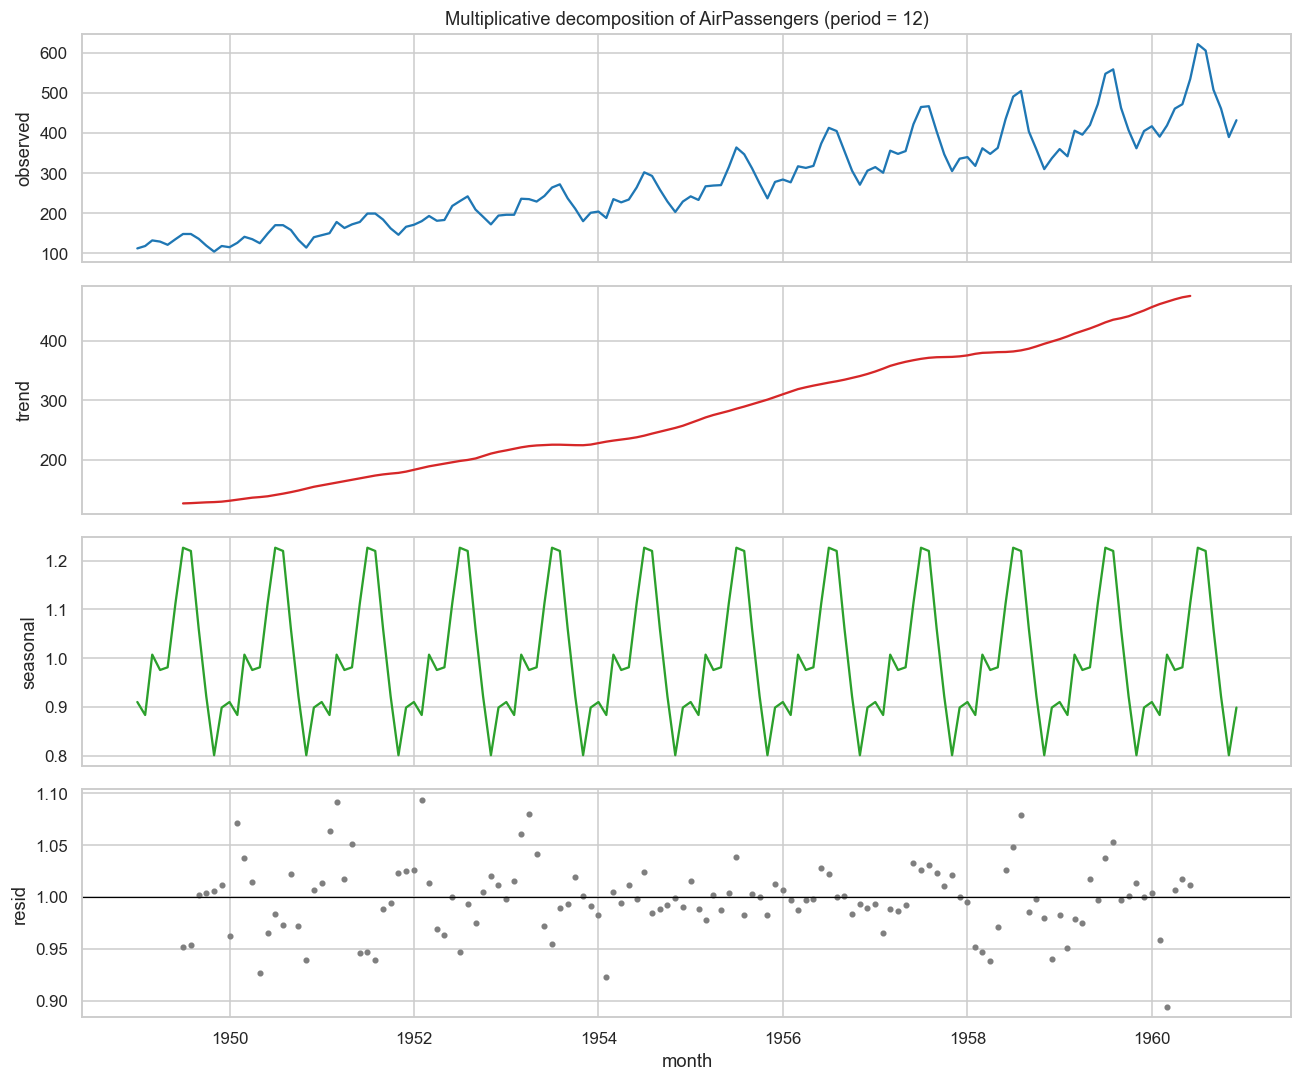

Residual std — multiplicative (ratio scale): 0.0334
Residual std — additive      (scaled)      : 0.0690

Seasonal index (multiplicative, 1.0 = average month):
Month
1    0.910
2    0.884
3    1.007
4    0.976
5    0.981
6    1.113
7    1.227
8    1.220
9    1.060
10   0.922
11   0.801
12   0.899


In [12]:
def classical_decompose(data, period=SEASONAL_PERIOD, model="multiplicative"):
    """Classical seasonal decomposition with a 2xperiod centred moving average."""
    # symmetric weights: half weight on the two end points (even period)
    weights = np.full(period + 1, 1 / period)
    weights[0] = weights[-1] = 1 / (2 * period)
    trend = data.rolling(period + 1, center=True).apply(
        lambda w: np.dot(w, weights), raw=True)

    detrended = data / trend if model == "multiplicative" else data - trend

    monthly = detrended.groupby(detrended.index.month).mean()
    monthly = monthly / monthly.mean() if model == "multiplicative" else monthly - monthly.mean()
    seasonal = pd.Series(data.index.month.map(monthly), index=data.index)

    resid = data / (trend * seasonal) if model == "multiplicative" else data - trend - seasonal
    return pd.DataFrame({"observed": data, "trend": trend,
                         "seasonal": seasonal, "resid": resid}), monthly


dec_mul, seasonal_index = classical_decompose(series, model="multiplicative")
dec_add, _ = classical_decompose(series, model="additive")

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
for ax, comp, colour in zip(axes, ["observed", "trend", "seasonal", "resid"],
                            ["#1f77b4", "#d62728", "#2ca02c", "#7f7f7f"]):
    axes_style = dict(lw=1.5, color=colour)
    if comp == "resid":
        ax.plot(dec_mul.index, dec_mul[comp], marker="o", ms=3, ls="", color=colour)
        ax.axhline(1.0, color="black", lw=.8)
    else:
        ax.plot(dec_mul.index, dec_mul[comp], **axes_style)
    ax.set_ylabel(comp)
axes[0].set_title("Multiplicative decomposition of AirPassengers (period = 12)")
axes[-1].set_xlabel("month")
plt.tight_layout()
plt.show()

resid_strength = {
    "multiplicative": dec_mul["resid"].std(),
    "additive": dec_add["resid"].std() / series.mean(),   # scaled to be comparable
}
print(f"Residual std — multiplicative (ratio scale): {resid_strength['multiplicative']:.4f}")
print(f"Residual std — additive      (scaled)      : {resid_strength['additive']:.4f}")
print("\nSeasonal index (multiplicative, 1.0 = average month):")
print(seasonal_index.round(3).to_string())

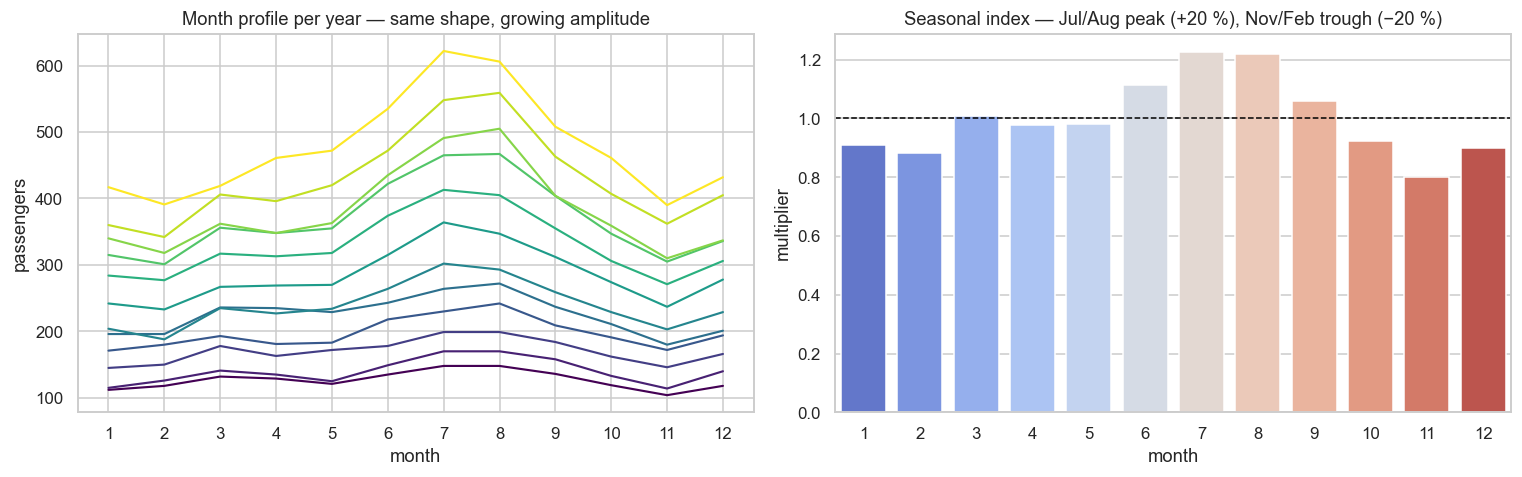

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# year-over-year month profile
pivot = pd.DataFrame({"year": series.index.year, "month": series.index.month,
                      "value": series.values}).pivot(index="month", columns="year",
                                                     values="value")
pivot.plot(ax=axes[0], cmap="viridis", lw=1.4, legend=False)
axes[0].set_title("Month profile per year — same shape, growing amplitude")
axes[0].set_xlabel("month")
axes[0].set_ylabel("passengers")
axes[0].set_xticks(range(1, 13))

sns.barplot(x=seasonal_index.index, y=seasonal_index.values, ax=axes[1],
            palette="coolwarm")
axes[1].axhline(1.0, color="black", lw=1, ls="--")
axes[1].set_title("Seasonal index — Jul/Aug peak (+20 %), Nov/Feb trough (−20 %)")
axes[1].set_xlabel("month")
axes[1].set_ylabel("multiplier")

plt.tight_layout()
plt.show()

### 2.8 Autocorrelation — why lag features work at all

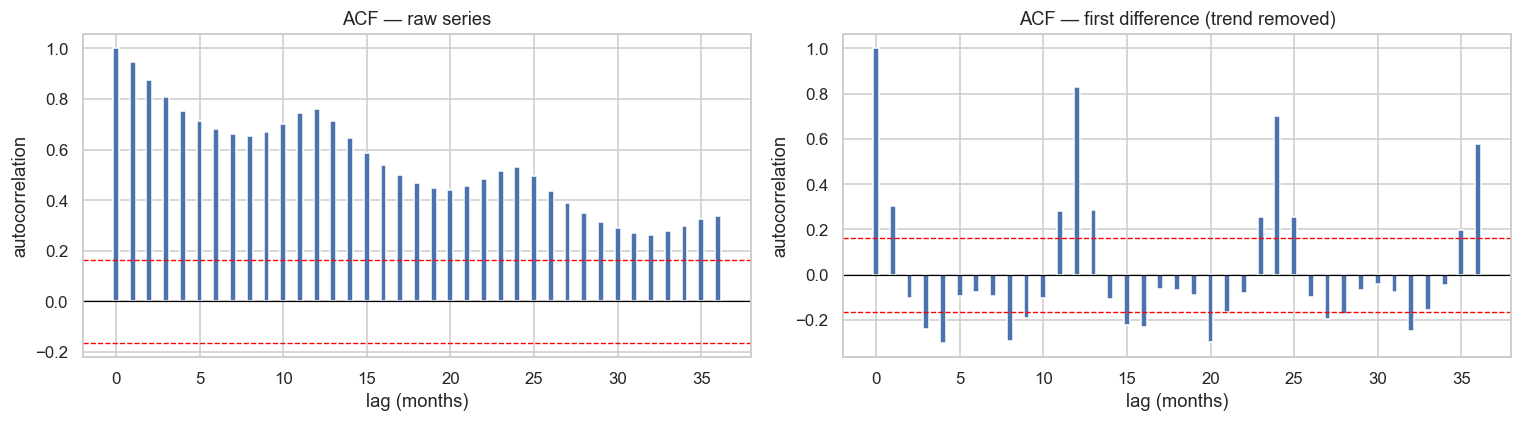

ACF of the raw series, lags 1-12:
1    0.948
2    0.876
3    0.807
4    0.753
5    0.714
6    0.682
7    0.663
8    0.656
9    0.671
10   0.703
11   0.743
12   0.760

95% white-noise band: +/-0.163
Every lag inside the 6-month window is far outside the band -> all six lags carry real signal, lag_1 the most.


In [14]:
def acf(x, nlags=36):
    """Sample autocorrelation function (numpy-only, matches statsmodels' biased ACF)."""
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    denom = np.dot(x, x)
    return np.array([np.dot(x[:len(x) - k], x[k:]) / denom for k in range(nlags + 1)])


nlags = 36
ac_raw = acf(series, nlags)
ac_diff = acf(series.diff(1).dropna(), nlags)          # first difference removes the trend
ci = 1.96 / np.sqrt(len(series))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, values, title in [(axes[0], ac_raw, "ACF — raw series"),
                          (axes[1], ac_diff, "ACF — first difference (trend removed)")]:
    ax.bar(range(nlags + 1), values, width=.35, color="#4c72b0")
    ax.axhline(0, color="black", lw=.8)
    ax.axhline(ci, color="red", ls="--", lw=.9)
    ax.axhline(-ci, color="red", ls="--", lw=.9)
    ax.set_title(title)
    ax.set_xlabel("lag (months)")
    ax.set_ylabel("autocorrelation")
plt.tight_layout()
plt.show()

print("ACF of the raw series, lags 1-12:")
print(pd.Series(ac_raw[1:13], index=range(1, 13)).round(3).to_string())
print(f"\n95% white-noise band: +/-{ci:.3f}")
print("Every lag inside the 6-month window is far outside the band -> "
      "all six lags carry real signal, lag_1 the most.")

### 2.9 EDA findings

1. **Strong upward trend** — traffic rises from 112 (Jan 1949) to 432 (Dec 1960), peaking
   at **622 in Jul 1960**; **+286 %** end to end, roughly **+13 % year over year**.
2. **Multiplicative seasonality** with period 12 — a July/August peak (≈ **+22 %** above
   the average month) and a November trough (≈ **−20 %**). The rolling standard deviation
   grows with the level, and the multiplicative decomposition leaves a residual roughly
   **half** as noisy as the additive one (std 0.033 vs 0.069), confirming that the
   seasonal swing scales with the trend.
3. **Right-skewed, non-normal target** (skew ≈ 0.57, Shapiro–Wilk p ≈ 2.6e-4) with growing
   variance — a natural candidate for a log transform.
4. **Very high autocorrelation** — the raw ACF decays slowly and never enters the ±0.163
   white-noise band (non-stationary), and it turns *back up* from lag 8 to lag 12 — the
   seasonal signature. `lag_1` correlates **0.958** with the target, and even `lag_6` still
   **0.784**. This is precisely what makes the sliding-window formulation viable.
5. **Consequence for modelling:** the test window (1959-09 → 1960-12) contains passenger
   counts *higher than anything in training*, so the model is asked to extrapolate — the
   hardest possible ask for a tree/transformer-based tabular learner.

## 3. Model Training with `TabPFNRegressor`

### 3.1 Scaling

TabPFN normalises its inputs internally, but an explicit `StandardScaler` is fitted here
so the exact same transform can be re-applied by the REST API. **The scaler is fitted on
the training window only** — fitting on all data would leak future statistics into the past.

In [15]:
scaler = StandardScaler().fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Scaler fitted on {X_train.shape[0]} training rows only")
print(f"train mean/std after scaling: {X_train_scaled.mean():+.3f} / {X_train_scaled.std():.3f}")
print(f"test  mean/std after scaling: {X_test_scaled.mean():+.3f} / {X_test_scaled.std():.3f}"
      "   <- shifted up: the test period is outside the training range")

Scaler fitted on 110 training rows only
train mean/std after scaling: -0.000 / 1.000
test  mean/std after scaling: +2.284 / 0.888   <- shifted up: the test period is outside the training range


### 3.2 Train the model

In [16]:
from tabpfn import TabPFNRegressor

model = TabPFNRegressor(device="cpu", random_state=RANDOM_STATE)

t0 = time.perf_counter()
model.fit(X_train_scaled, y_train)
fit_seconds = time.perf_counter() - t0

y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

print(f"TabPFNRegressor fitted in {fit_seconds:.2f}s on {X_train.shape[0]} rows "
      f"x {X_train.shape[1]} features")
print(f"first 5 test predictions: {np.round(y_pred_test[:5], 1)}")
print(f"first 5 test actuals    : {y_test.head().to_numpy()}")

TabPFNRegressor fitted in 0.15s on 110 rows x 6 features
first 5 test predictions: [447.5 348.2 318.8 339.6 353.2]
first 5 test actuals    : [404 359 310 337 360]


### 3.3 Evaluation metrics

In [17]:
def evaluate(y_true, y_pred, label):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mse = mean_squared_error(y_true, y_pred)
    return {
        "set": label,
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "MAPE %": np.mean(np.abs((y_true - y_pred) / y_true)) * 100,
    }


metrics = pd.DataFrame([
    evaluate(y_train, y_pred_train, "train"),
    evaluate(y_test, y_pred_test, "test"),
]).set_index("set")

metrics

,MSE,RMSE,MAE,R2,MAPE %
set,,,,,
train,62.814,7.926,5.654,0.993,2.529
test,"1,149.460",33.904,24.073,0.814,5.150


### 3.4 Baselines

A metric is meaningless without a reference point. Three baselines are evaluated on the
identical test window:

- **Naive / persistence** — predict last month's value (`lag_1`); the standard yardstick
  for one-step-ahead forecasting.
- **Seasonal naive** — predict the value 12 months earlier (taken from the raw series).
- **Linear regression** on the same six scaled lags.

In [18]:
naive_pred = X_test["lag_1"].to_numpy(dtype=float)
seasonal_naive_pred = series.shift(12).loc[X_test.index].to_numpy(dtype=float)

lin = LinearRegression().fit(X_train_scaled, y_train)
lin_pred = lin.predict(X_test_scaled)

comparison = pd.DataFrame([
    evaluate(y_test, naive_pred, "Naive (lag_1)"),
    evaluate(y_test, seasonal_naive_pred, "Seasonal naive (t-12)"),
    evaluate(y_test, lin_pred, "LinearRegression (6 lags)"),
    evaluate(y_test, y_pred_test, "TabPFNRegressor (6 lags)"),
]).set_index("set")

print("Test-set comparison (lower is better except R2):")
comparison.sort_values("RMSE")

Test-set comparison (lower is better except R2):


,MSE,RMSE,MAE,R2,MAPE %
set,,,,,
TabPFNRegressor (6 lags),"1,149.460",33.904,24.073,0.814,5.150
Seasonal naive (t-12),"2,147.786",46.344,41.429,0.652,9.207
LinearRegression (6 lags),"2,266.356",47.606,41.115,0.633,9.511
Naive (lag_1),"2,846.750",53.355,45.821,0.538,10.531


### 3.5 Actual vs predicted

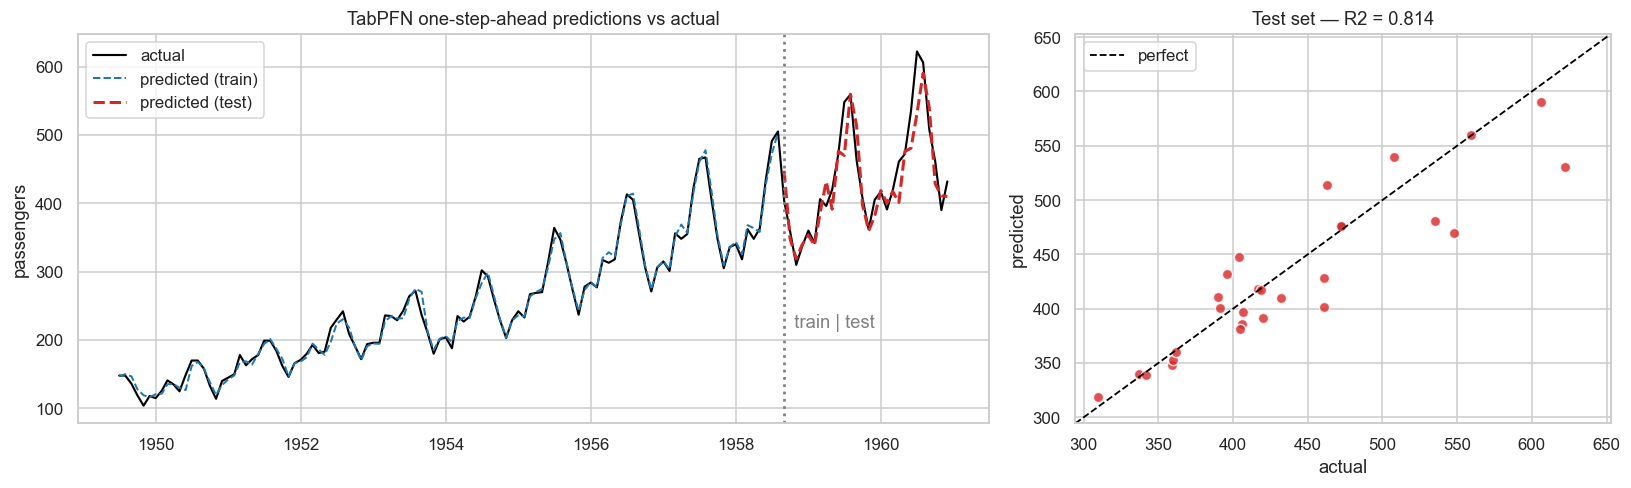

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.6),
                         gridspec_kw={"width_ratios": [1.7, 1]})

axes[0].plot(y.index, y.values, color="black", lw=1.4, label="actual")
axes[0].plot(X_train.index, y_pred_train, color="#1f77b4", lw=1.3, ls="--",
             label="predicted (train)")
axes[0].plot(X_test.index, y_pred_test, color="#d62728", lw=2, ls="--",
             label="predicted (test)")
axes[0].axvline(X_test.index[0], color="grey", ls=":", lw=1.8)
axes[0].text(X_test.index[0], y.max() * .35, "  train | test", color="grey")
axes[0].set_title("TabPFN one-step-ahead predictions vs actual")
axes[0].set_ylabel("passengers")
axes[0].legend(loc="upper left")

lo = float(min(y_test.min(), y_pred_test.min())) * .95
hi = float(max(y_test.max(), y_pred_test.max())) * 1.05
axes[1].scatter(y_test, y_pred_test, s=45, color="#d62728", alpha=.8, edgecolor="white")
axes[1].plot([lo, hi], [lo, hi], color="black", ls="--", lw=1.2, label="perfect")
axes[1].set_xlim(lo, hi); axes[1].set_ylim(lo, hi)
axes[1].set_xlabel("actual"); axes[1].set_ylabel("predicted")
axes[1].set_title(f"Test set — R2 = {metrics.loc['test', 'R2']:.3f}")
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.6 Residual analysis

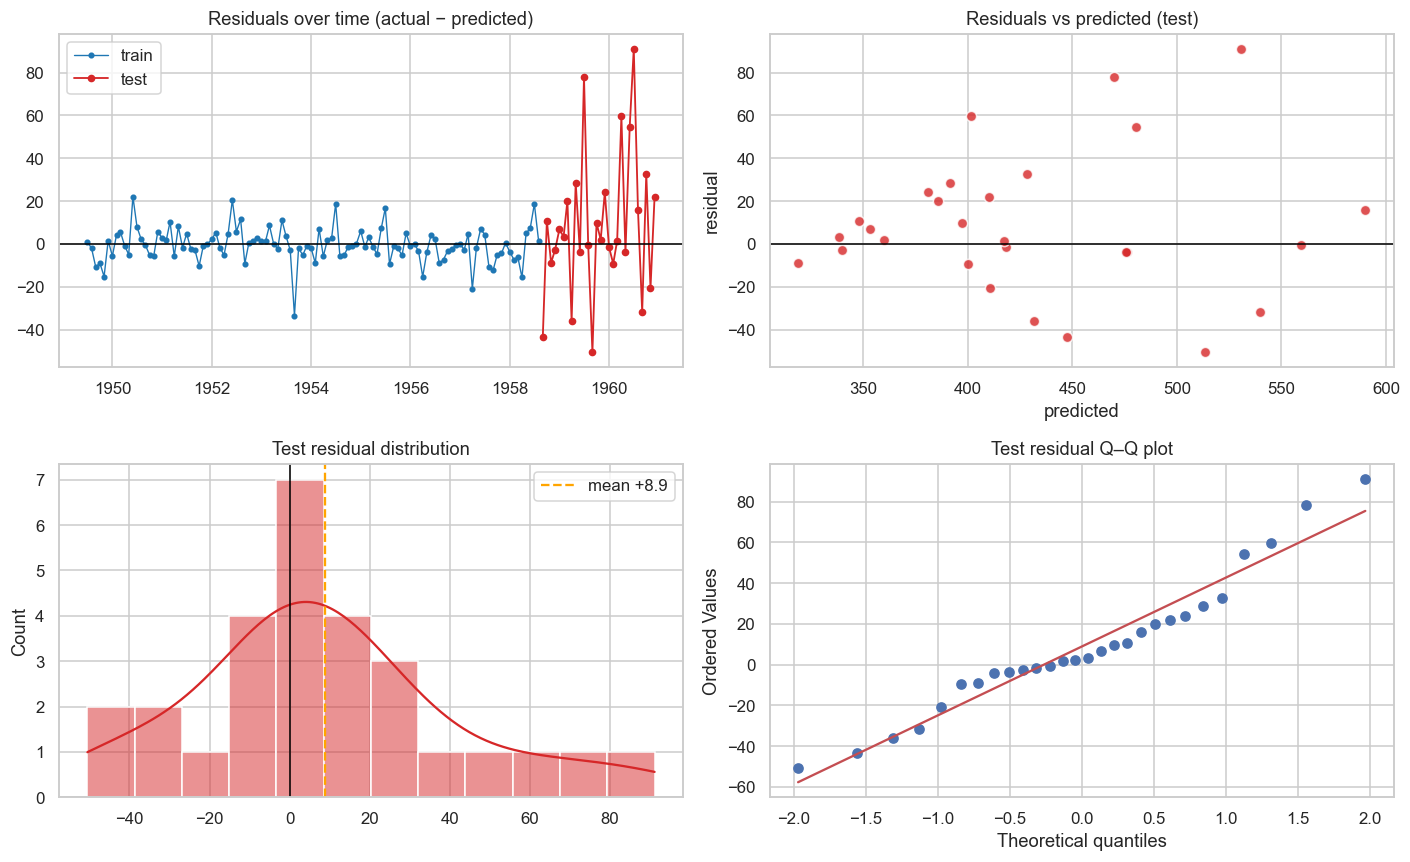

test residual mean : +8.87   (under-prediction bias)
test residual std  : 32.72
largest |residual| : 91.1 at 1960-07


In [20]:
resid_train = np.asarray(y_train, dtype=float) - y_pred_train
resid_test = np.asarray(y_test, dtype=float) - y_pred_test

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].plot(X_train.index, resid_train, "o-", ms=3, lw=.9, color="#1f77b4", label="train")
axes[0, 0].plot(X_test.index, resid_test, "o-", ms=4, lw=1.2, color="#d62728", label="test")
axes[0, 0].axhline(0, color="black", lw=1)
axes[0, 0].set_title("Residuals over time (actual − predicted)")
axes[0, 0].legend()

axes[0, 1].scatter(y_pred_test, resid_test, s=45, color="#d62728", alpha=.8, edgecolor="white")
axes[0, 1].axhline(0, color="black", lw=1)
axes[0, 1].set_xlabel("predicted"); axes[0, 1].set_ylabel("residual")
axes[0, 1].set_title("Residuals vs predicted (test)")

sns.histplot(resid_test, bins=12, kde=True, ax=axes[1, 0], color="#d62728")
axes[1, 0].axvline(0, color="black", lw=1)
axes[1, 0].axvline(resid_test.mean(), color="orange", ls="--",
                   label=f"mean {resid_test.mean():+.1f}")
axes[1, 0].set_title("Test residual distribution")
axes[1, 0].legend()

stats.probplot(resid_test, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Test residual Q–Q plot")

plt.tight_layout()
plt.show()

print(f"test residual mean : {resid_test.mean():+.2f}   "
      f"({'under' if resid_test.mean() > 0 else 'over'}-prediction bias)")
print(f"test residual std  : {resid_test.std():.2f}")
print(f"largest |residual| : {np.abs(resid_test).max():.1f} "
      f"at {X_test.index[np.abs(resid_test).argmax()]:%Y-%m}")

## 4. Model Interpretation

### 4.1 Which lags matter?

Permutation importance shuffles one feature at a time on the **test** set and measures how
far R² falls — a model-agnostic importance measure that works for TabPFN, which exposes no
coefficients.

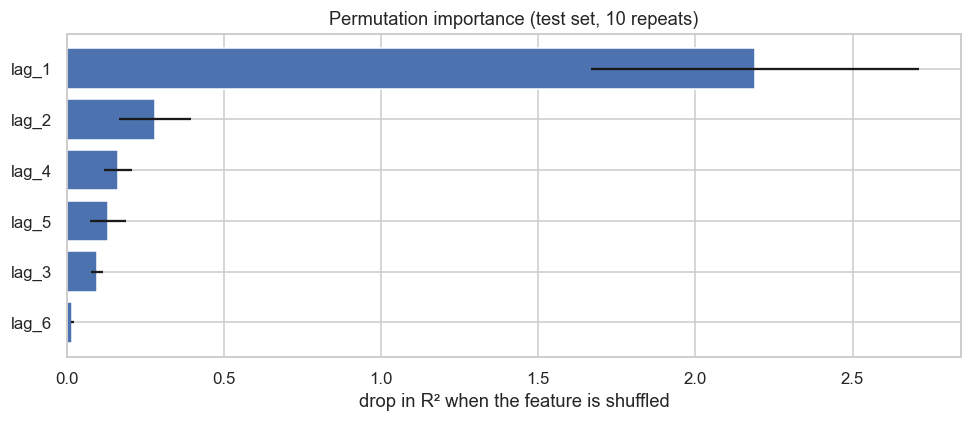

,feature,importance,std
0,lag_1,2.189,0.522
1,lag_2,0.280,0.115
2,lag_4,0.163,0.046
3,lag_5,0.132,0.057
4,lag_3,0.096,0.019
5,lag_6,0.017,0.005


In [21]:
perm = permutation_importance(
    model, X_test_scaled, y_test,
    n_repeats=10, random_state=RANDOM_STATE, scoring="r2",
)

importance = (pd.DataFrame({"feature": FEATURE_NAMES,
                            "importance": perm.importances_mean,
                            "std": perm.importances_std})
              .sort_values("importance", ascending=False))

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(importance["feature"], importance["importance"],
        xerr=importance["std"], color="#4c72b0")
ax.invert_yaxis()
ax.set_xlabel("drop in R² when the feature is shuffled")
ax.set_title("Permutation importance (test set, 10 repeats)")
plt.tight_layout()
plt.show()

importance.reset_index(drop=True)

### 4.2 Recursive multi-step forecast

The model is trained for **one-step-ahead** prediction. To forecast further out, its own
prediction is appended to the window and fed back in — the same loop a client of the REST
API would run. Error compounds with every step, so this is shown as a demonstration of the
mechanism **and of its limits**: the forecast below reproduces the seasonal shape but
flattens out instead of continuing to climb, because TabPFN cannot predict beyond the
target range it was trained on. Real 1961 traffic kept growing.

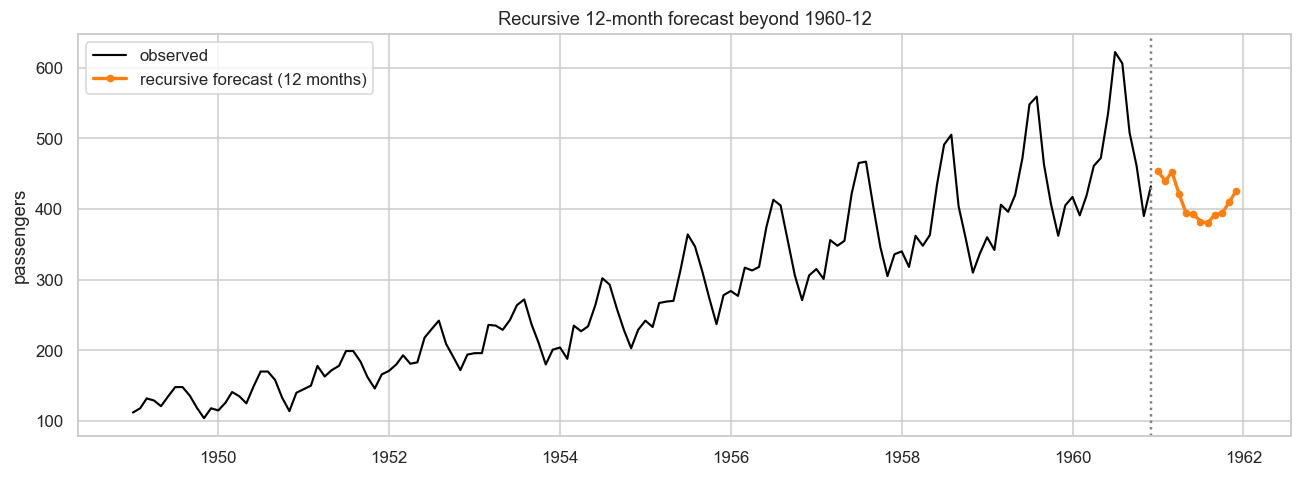

,1961-01,1961-02,1961-03,1961-04,1961-05,1961-06,1961-07,1961-08,1961-09,1961-10,1961-11,1961-12
forecast,453.100,439.500,452.600,420.800,393.700,393.500,382.000,380.200,392.200,393.900,409.400,426.000


In [22]:
def recursive_forecast(fitted_model, fitted_scaler, history, steps=12,
                       window_size=WINDOW_SIZE, feature_names=FEATURE_NAMES):
    """Feed predictions back into the window to forecast `steps` months ahead."""
    window = list(np.asarray(history, dtype=float)[-window_size:])
    preds = []
    for _ in range(steps):
        frame = pd.DataFrame([window], columns=feature_names)
        nxt = float(fitted_model.predict(fitted_scaler.transform(frame))[0])
        preds.append(nxt)
        window = window[1:] + [nxt]
    return np.array(preds)


HORIZON = 12
future_index = pd.date_range(series.index[-1] + pd.offsets.MonthBegin(),
                             periods=HORIZON, freq="MS")
future_pred = recursive_forecast(model, scaler, series.to_numpy(), steps=HORIZON)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(series.index, series.values, color="black", lw=1.4, label="observed")
ax.plot(future_index, future_pred, color="#ff7f0e", lw=2.2, marker="o", ms=4,
        label=f"recursive forecast ({HORIZON} months)")
ax.axvline(series.index[-1], color="grey", ls=":", lw=1.6)
ax.set_title("Recursive 12-month forecast beyond 1960-12")
ax.set_ylabel("passengers")
ax.legend()
plt.tight_layout()
plt.show()

pd.DataFrame({"forecast": future_pred.round(1)},
             index=future_index.strftime("%Y-%m")).T

### 4.3 Persist the model, scaler and metadata

In [23]:
joblib.dump(model, MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)

metadata = {
    "model": "TabPFNRegressor",
    "tabpfn_device": "cpu",
    "window_size": WINDOW_SIZE,
    "feature_names": FEATURE_NAMES,
    "feature_order": "oldest -> newest (lag_6 ... lag_1)",
    "target": "#Passengers (next month)",
    "train_period": [f"{X_train.index.min():%Y-%m}", f"{X_train.index.max():%Y-%m}"],
    "test_period": [f"{X_test.index.min():%Y-%m}", f"{X_test.index.max():%Y-%m}"],
    "n_train": int(len(X_train)),
    "n_test": int(len(X_test)),
    "random_state": RANDOM_STATE,
    "metrics": {row: {k: float(v) for k, v in metrics.loc[row].items()}
                for row in metrics.index},
    "scaler": "StandardScaler (fitted on training rows only)",
}
META_PATH.write_text(json.dumps(metadata, indent=2))

for path in (MODEL_PATH, SCALER_PATH, SUPERVISED_CSV, META_PATH):
    print(f"{path.name:45s} {path.stat().st_size / 1024:10,.1f} KB")

tabpfn_timeseries_regression_model.pkl          43,553.3 KB
timeseries_regression_scaler.pkl                     1.1 KB
timeseries_regression_supervised.csv                 6.9 KB
timeseries_regression_metadata.json                  0.9 KB


### 4.4 Discussion, and how it lines up with the EDA

**Performance.** TabPFN reaches **R² ≈ 0.81, RMSE ≈ 34, MAE ≈ 24 (MAPE ≈ 5 %)** on 28
future months it never saw, and it beats every baseline on the same window — persistence
(RMSE 53.4), linear regression on the same six lags (47.6) and even the seasonal-naive
rule (46.3). Train error is far lower (R² 0.993, RMSE 7.9), but that gap is *not* mainly
overfitting: the test window is the highest-traffic stretch of the whole series (targets
up to 622 vs a training maximum of 505), so the model is being asked to extrapolate past
its training range (§1.3, §3.1).

**Feature importance vs EDA.** Permutation importance ranks `lag_1` far ahead of the rest
(ΔR² ≈ 2.19 vs ≈ 0.28 for `lag_2`), matching the correlation analysis in §2.5 (ρ = 0.958)
and the ACF in §2.8. `lag_6` contributes least (≈ 0.02) — it is the noisiest of the six and
the model can largely reconstruct it from the others. No lag in the window reaches back a
full year, so the lag-12 seasonal term visible in §2.8 is unavailable; seasonality is
captured only *implicitly*, from the shape of the last six months.

**Residuals.** The mean test residual is **+8.9** — a mild under-prediction bias — and the
single worst miss, **91 passengers, lands on 1960-07**, the all-time seasonal peak. That is
the fingerprint of a rising trend plus a growing seasonal amplitude that the model cannot
extrapolate, exactly as the non-stationarity in §2.2 predicts.

### 4.5 Limitations

- **Extrapolation.** TabPFN, like tree ensembles, predicts within the target range it saw
  during training. On a series with a persistent upward trend this systematically
  under-predicts the future.
- **Window too short for seasonality.** `WINDOW_SIZE = 6` cannot represent the lag-12
  seasonal term directly. A 12- or 13-lag window, or explicit calendar features, would.
- **Six observations lost.** The first `WINDOW_SIZE` months are dropped by the transformation.
- **One-step-ahead only.** Multi-step needs the recursive loop of §4.2, where errors compound.
- **Small data.** 138 supervised rows, 28 of them for testing — metrics carry wide
  uncertainty, and a single split is a fragile estimate.
- **No uncertainty in the API.** Only a point forecast is returned.

### 4.6 How to improve it

1. **Log-transform the target** (`log(y)` → fit → `exp`) to convert multiplicative
   seasonality and growing variance into additive, constant-variance behaviour.
2. **De-trend or difference** — model `y_t − y_{t−1}` or `y_t / y_{t−12}` so the target
   stays inside the range the model has seen.
3. **Widen the window to ≥ 12** and add explicit features: month-of-year, rolling
   mean/std, year index.
4. **Rolling-origin cross-validation** (`TimeSeriesSplit`) instead of one fixed split.
5. **Retrain regularly** as new months arrive, and monitor drift.

## 5. REST API Service (Flask)

The service loads the pickled model, scaler and metadata **once at startup**, then exposes:

| Method & path | Purpose |
|---|---|
| `GET /` | service description |
| `GET /health` | health / readiness probe |
| `POST /predict` | predict next month from the last 6 months |

Input validation rejects: non-JSON bodies, a missing/mis-named `passengers` field, a list
whose length is not exactly 6, non-numeric values, `NaN`/`inf`, and negative values. Every
error path returns JSON, never an HTML traceback.

In [24]:
%%writefile timeseries_regression_api.py
"""
Flask REST API for the AirPassengers sliding-window regression model.

Loads the TabPFN model + StandardScaler produced by
`timeseries_regression_solution.ipynb` and predicts next month's passenger
count from the previous 6 months.

Run:
    cd Week2
    ./.venv/bin/python Day_1/timeseries_regression_api.py          # port 5001
    PORT=8080 ./.venv/bin/python Day_1/timeseries_regression_api.py

Example:
    curl -X POST http://localhost:5001/predict \
         -H "Content-Type: application/json" \
         -d '{"passengers": [417, 391, 419, 461, 472, 535]}'
"""
import json
import math
import os
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from flask import Flask, jsonify, request

BASE_DIR = Path(__file__).resolve().parent
MODEL_PATH = BASE_DIR / "tabpfn_timeseries_regression_model.pkl"
SCALER_PATH = BASE_DIR / "timeseries_regression_scaler.pkl"
META_PATH = BASE_DIR / "timeseries_regression_metadata.json"

app = Flask(__name__)

# ---- load artifacts once at startup --------------------------------------
_missing = [p.name for p in (MODEL_PATH, SCALER_PATH, META_PATH) if not p.exists()]
if _missing:
    raise FileNotFoundError(
        f"Missing artifact(s): {', '.join(_missing)}. "
        "Run timeseries_regression_solution.ipynb first."
    )

MODEL = joblib.load(MODEL_PATH)
SCALER = joblib.load(SCALER_PATH)
METADATA = json.loads(META_PATH.read_text())

WINDOW_SIZE = METADATA["window_size"]
FEATURE_NAMES = METADATA["feature_names"]


def _validate(payload):
    """Return (values, None) on success or (None, (json_error, status))."""
    if not isinstance(payload, dict):
        return None, ({"error": "Request body must be a JSON object."}, 400)

    if "passengers" not in payload:
        return None, ({"error": "Missing required field 'passengers'.",
                       "expected": f"a list of {WINDOW_SIZE} numbers, oldest -> newest"}, 400)

    values = payload["passengers"]
    if not isinstance(values, (list, tuple)):
        return None, ({"error": "'passengers' must be a list of numbers.",
                       "received_type": type(values).__name__}, 400)

    if len(values) != WINDOW_SIZE:
        return None, ({"error": f"'passengers' must contain exactly {WINDOW_SIZE} values.",
                       "received_length": len(values)}, 400)

    clean = []
    for i, v in enumerate(values):
        if isinstance(v, bool) or not isinstance(v, (int, float)):
            return None, ({"error": f"Value at index {i} is not numeric.",
                           "value": v}, 400)
        v = float(v)
        if not math.isfinite(v):
            return None, ({"error": f"Value at index {i} is not finite (NaN/inf)."}, 400)
        if v < 0:
            return None, ({"error": f"Value at index {i} is negative; "
                                    "passenger counts must be >= 0.", "value": v}, 400)
        clean.append(v)

    return clean, None


@app.get("/")
def index():
    return jsonify({
        "service": "AirPassengers next-month forecaster",
        "model": METADATA["model"],
        "window_size": WINDOW_SIZE,
        "feature_order": METADATA["feature_order"],
        "trained_on": METADATA["train_period"],
        "test_r2": round(METADATA["metrics"]["test"]["R2"], 4),
        "endpoints": {
            "GET /health": "health check",
            "POST /predict": {
                "body": {"passengers": [f"<{WINDOW_SIZE} numbers, oldest -> newest>"]},
                "returns": {"predicted_next_month": "<float>"},
            },
        },
    })


@app.get("/health")
def health():
    return jsonify({"status": "ok", "model_loaded": MODEL is not None,
                    "scaler_loaded": SCALER is not None,
                    "window_size": WINDOW_SIZE})


@app.post("/predict")
def predict():
    payload = request.get_json(silent=True)
    if payload is None:
        return jsonify({"error": "Body must be valid JSON with "
                                 "Content-Type: application/json."}), 400

    values, err = _validate(payload)
    if err is not None:
        body, status = err
        return jsonify(body), status

    try:
        frame = pd.DataFrame([values], columns=FEATURE_NAMES)
        prediction = float(MODEL.predict(SCALER.transform(frame))[0])
    except Exception as exc:                       # inference failure
        app.logger.exception("prediction failed")
        return jsonify({"error": "Prediction failed.", "detail": str(exc)}), 500

    last = values[-1]
    return jsonify({
        "input_passengers": values,
        "predicted_next_month": round(prediction, 2),
        "change_vs_last_month": round(prediction - last, 2),
        "change_vs_last_month_pct": round((prediction / last - 1) * 100, 2) if last else None,
        "window_size": WINDOW_SIZE,
        "model": METADATA["model"],
    })


@app.errorhandler(404)
def not_found(_):
    return jsonify({"error": "Not found.",
                    "available": ["GET /", "GET /health", "POST /predict"]}), 404


@app.errorhandler(405)
def not_allowed(_):
    return jsonify({"error": "Method not allowed for this endpoint."}), 405


if __name__ == "__main__":
    port = int(os.environ.get("PORT", 5001))   # 5000 is taken by AirPlay on macOS
    app.run(host="0.0.0.0", port=port, debug=False)

Writing timeseries_regression_api.py


### 5.1 Smoke-test the API in-process

`app.test_client()` exercises the real routing, validation and inference stack without
binding a port — so this runs safely inside the notebook.

In [25]:
import importlib.util

spec = importlib.util.spec_from_file_location("ts_api", API_PATH)
ts_api = importlib.util.module_from_spec(spec)
spec.loader.exec_module(ts_api)

client = ts_api.app.test_client()

last_six = series.iloc[-WINDOW_SIZE:].tolist()
print(f"last 6 observed months ({series.index[-WINDOW_SIZE]:%Y-%m} -> "
      f"{series.index[-1]:%Y-%m}): {last_six}\n")

checks = [
    ("GET  /health",              client.get("/health")),
    ("POST /predict  valid",      client.post("/predict", json={"passengers": last_six})),
    ("POST /predict  5 values",   client.post("/predict", json={"passengers": last_six[:5]})),
    ("POST /predict  no field",   client.post("/predict", json={"months": last_six})),
    ("POST /predict  non-numeric", client.post("/predict",
                                               json={"passengers": ["a"] + last_six[1:]})),
    ("POST /predict  negative",   client.post("/predict",
                                              json={"passengers": [-1] + last_six[1:]})),
    ("POST /predict  not JSON",   client.post("/predict", data="hello")),
    ("GET  /unknown",             client.get("/unknown")),
    ("GET  /predict (wrong verb)", client.get("/predict")),
]

for label, resp in checks:
    body = resp.get_json()
    shown = body.get("predicted_next_month", body.get("error", body.get("status")))
    print(f"{label:30s} -> {resp.status_code}  {shown}")

last 6 observed months (1960-07 -> 1960-12): [622, 606, 508, 461, 390, 432]



GET  /health                   -> 200  ok
POST /predict  valid           -> 200  453.1
POST /predict  5 values        -> 400  'passengers' must contain exactly 6 values.
POST /predict  no field        -> 400  Missing required field 'passengers'.
POST /predict  non-numeric     -> 400  Value at index 0 is not numeric.
POST /predict  negative        -> 400  Value at index 0 is negative; passenger counts must be >= 0.
POST /predict  not JSON        -> 400  Body must be valid JSON with Content-Type: application/json.
GET  /unknown                  -> 404  Not found.
GET  /predict (wrong verb)     -> 405  Method not allowed for this endpoint.


### 5.2 Running it for real

```bash
cd "Week2"

# the environment already contains flask + tabpfn (see pyproject.toml)
uv sync                                            # or: uv run --help

# default port 5001 (macOS AirPlay occupies 5000)
./.venv/bin/python Day_1/timeseries_regression_api.py
# or pick another port
PORT=8080 ./.venv/bin/python Day_1/timeseries_regression_api.py
```

Then, from another terminal:

```bash
curl http://localhost:5001/health

curl -X POST http://localhost:5001/predict \
     -H "Content-Type: application/json" \
     -d '{"passengers": [417, 391, 419, 461, 472, 535]}'
```

```json
{
  "input_passengers": [417.0, 391.0, 419.0, 461.0, 472.0, 535.0],
  "predicted_next_month": 530.92,
  "change_vs_last_month": -4.08,
  "change_vs_last_month_pct": -0.76,
  "window_size": 6,
  "model": "TabPFNRegressor"
}
```

> **Note on the port:** if you see `[Errno 48] address already in use`, another process
> holds the port — `lsof -nP -iTCP:5001 -sTCP:LISTEN` then `kill <PID>`, or just start on
> a different `PORT`.